# AirPods Pro 2 Sentiment Analysis and Customer Insight Project

## Course: Big Data Analytics  
## Project Title: Sentiment Analysis and Customer Feedback Insights for AirPods Pro 2

---

## Group Details

**Group Number:** 14

B2025123 - Giridhar Sharma

B2025151 - Prajwal Vijay Nikhar

B2025154 - Ritik Tibrewal

B2025155 - Rohan Jain

---

## Project Objective

The objective of this project is to analyze customer reviews of **AirPods Pro 2** to understand user sentiment, identify key product strengths and weaknesses, and generate actionable business insights.  

Using **Natural Language Processing (NLP)** techniques such as **sentiment analysis, topic modeling, and clustering**, the project aims to uncover patterns in customer feedback and translate them into strategic recommendations for product improvement and marketing strategy.

---

## Dataset Description

The dataset consists of **customer reviews scraped from online platforms**, containing the following attributes:

- Review text
- Rating (Out of 5)
- Date of review
- Verified purchase status
- Likes and dislikes on reviews

These reviews provide valuable insights into **customer satisfaction, product performance, and areas for improvement**.

---

## Methodology Overview

The analysis follows these key steps:

1. **Data Collection and Cleaning**
2. **Exploratory Data Analysis (EDA)**
3. **Sentiment Classification**
4. **Topic Modeling using LDA**
5. **Customer Review Clustering**
6. **Business Insight Extraction**
7. **Strategic Recommendations**

---

## Tools and Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- NLP Libraries
- Matplotlib & Seaborn
- WordCloud
- Topic Modeling (LDA)

In [1]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # For lemmatization support

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from transformers import pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [3]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [4]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [5]:
review_df = pd.read_excel('AirPods-Pro-2-scrapped.xlsx')
review_df.head()

,Date,Name,Rating (Out of 5),Verified Purchase?,Review,Liked,Disliked
0,"Nov 16, 2024",WalmartCustomer,5,Verified Purchase,Walmart please change your policies to allow p...,-2,0
1,"May 13, 2024",Boworn,5,Verified Purchase,When I ordered for the first time The system s...,-99,-9
2,"Mar 2, 2024",Chase,5,Verified Purchase,One of my most favorite parts of these is the ...,-112,-2
3,"Dec 4, 2024",Mary,5,Seller Verified Purchase,I gifted these to my husband for his birthday ...,-1,0
4,"Oct 22, 2024",Andria,5,Seller Verified Purchase,"Very good, they start and stop music without m...",-1,0


In [6]:
# Dataset overview
print("Total Reviews:", len(review_df))
review_df.info()

Total Reviews: 8300
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8300 entries, 0 to 8299
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                8300 non-null   object
 1   Name                8299 non-null   object
 2   Rating (Out of 5)   8300 non-null   int64 
 3   Verified Purchase?  7978 non-null   object
 4   Review              8297 non-null   object
 5   Liked               8300 non-null   int64 
 6   Disliked            8300 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 454.0+ KB


In [7]:
import pandas as pd

# Create sentiment label from ratings
def sentiment_label(rating):
    if rating >= 4:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"

review_df["sentiment"] = review_df["Rating (Out of 5)"].apply(sentiment_label)

review_df.head()

,Date,Name,Rating (Out of 5),Verified Purchase?,Review,Liked,Disliked,sentiment
0,"Nov 16, 2024",WalmartCustomer,5,Verified Purchase,Walmart please change your policies to allow p...,-2,0,positive
1,"May 13, 2024",Boworn,5,Verified Purchase,When I ordered for the first time The system s...,-99,-9,positive
2,"Mar 2, 2024",Chase,5,Verified Purchase,One of my most favorite parts of these is the ...,-112,-2,positive
3,"Dec 4, 2024",Mary,5,Seller Verified Purchase,I gifted these to my husband for his birthday ...,-1,0,positive
4,"Oct 22, 2024",Andria,5,Seller Verified Purchase,"Very good, they start and stop music without m...",-1,0,positive


In [8]:
print("Total Reviews:", len(review_df))

print("\nSentiment Distribution:")
print(review_df["sentiment"].value_counts())

print("\nRating Distribution:")
print(review_df["Rating (Out of 5)"].value_counts())

Total Reviews: 8300

Sentiment Distribution:
sentiment
positive    7500
negative     635
neutral      165
Name: count, dtype: int64

Rating Distribution:
Rating (Out of 5)
5    7122
1     566
4     378
3     165
2      69
Name: count, dtype: int64


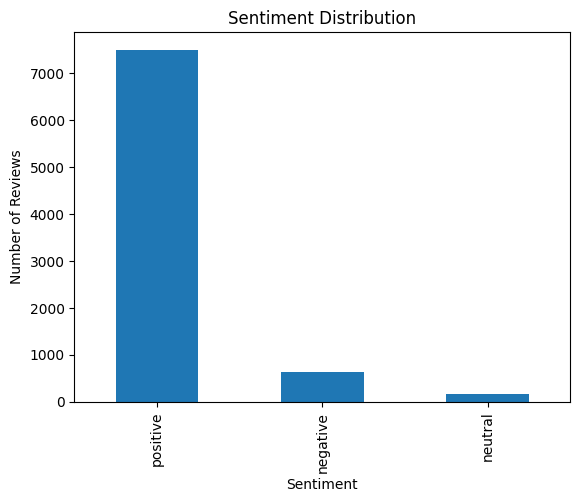

In [9]:
import matplotlib.pyplot as plt

review_df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

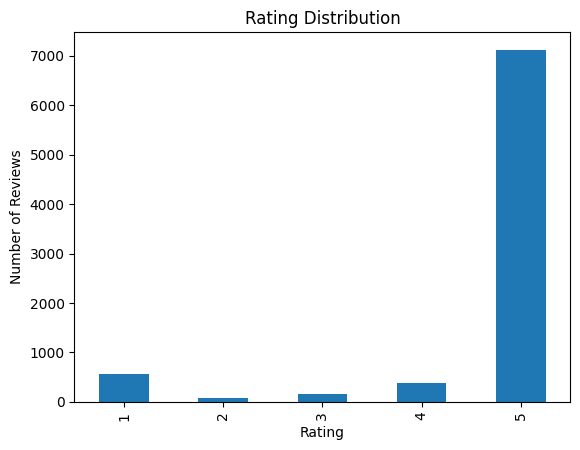

In [10]:
review_df["Rating (Out of 5)"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [11]:
review_df.shape

(8300, 8)

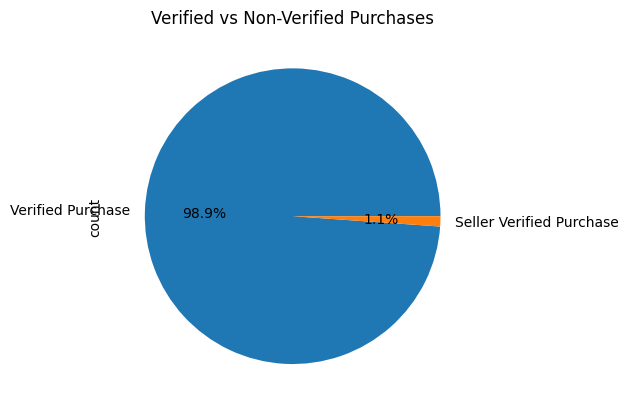

In [12]:
review_df["Verified Purchase?"].value_counts().plot(kind="pie", autopct='%1.1f%%')

plt.title("Verified vs Non-Verified Purchases")

plt.show()

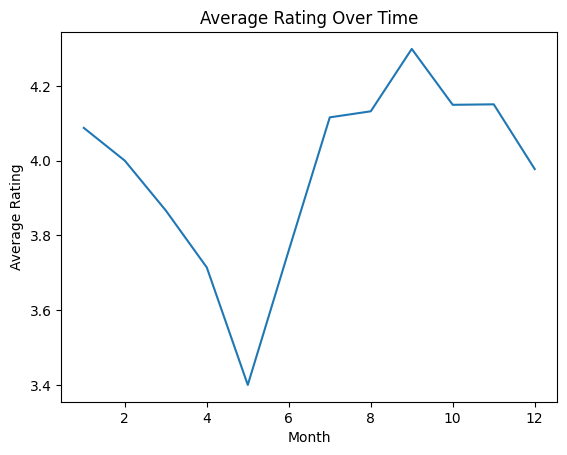

In [13]:
review_df["Date"] = pd.to_datetime(review_df["Date"], errors='coerce')

# Filter out rows where 'Date' conversion resulted in NaT
valid_dates_df = review_df.dropna(subset=['Date'])

valid_dates_df.groupby(valid_dates_df["Date"].dt.month)["Rating (Out of 5)"].mean().plot()

plt.title("Average Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")

plt.show()

In [14]:
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
VERB_CODES = {'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'}

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [15]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import re
import random

def convert_to_date(date_str):
    try:
        # Case 1: Direct date conversion
        return datetime.strptime(date_str, "%b %d, %Y").strftime("%Y-%m-%d")
    except ValueError:
        pass

    # Case 2: Relative date conversion (e.g., "1 year ago", "7 months ago", "12 hours ago")
    match = re.match(r"(\d+) (\w+) ago", date_str)
    if match:
        num, unit = int(match.group(1)), match.group(2)
        today = datetime.today()

        if "month" in unit:
            return (today - relativedelta(months=num)).strftime("%Y-%m-%d")
        elif "day" in unit:
            return (today - timedelta(days=num)).strftime("%Y-%m-%d")
        elif "hour" in unit:
            return (today - timedelta(hours=num)).strftime("%Y-%m-%d")  # Keeping only date
        elif "week" in unit:
            return (today - timedelta(weeks=num)).strftime("%Y-%m-%d")
        elif "year" in unit:
            # Pick a random date in the past year
            random_days = random.randint(1, 365)
            return (today - timedelta(days=random_days)).strftime("%Y-%m-%d")

    return "Invalid date format"

In [16]:
review_df["Date"]

,Date
0,2024-11-16
1,2024-05-13
2,2024-03-02
3,2024-12-04
4,2024-10-22
...,...
8295,NaT
8296,NaT
8297,NaT
8298,NaT


In [17]:
review_df["Liked"] = review_df["Liked"].abs()
review_df["Disliked"] = review_df["Disliked"].abs()
review_df.head()

,Date,Name,Rating (Out of 5),Verified Purchase?,Review,Liked,Disliked,sentiment
0,2024-11-16,WalmartCustomer,5,Verified Purchase,Walmart please change your policies to allow p...,2,0,positive
1,2024-05-13,Boworn,5,Verified Purchase,When I ordered for the first time The system s...,99,9,positive
2,2024-03-02,Chase,5,Verified Purchase,One of my most favorite parts of these is the ...,112,2,positive
3,2024-12-04,Mary,5,Seller Verified Purchase,I gifted these to my husband for his birthday ...,1,0,positive
4,2024-10-22,Andria,5,Seller Verified Purchase,"Very good, they start and stop music without m...",1,0,positive


In [18]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
VERB_CODES = {'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'}

In [19]:
# Ensure "Review" column is a string and drop extra columns
review_df = review_df.loc[:, ~review_df.columns.str.contains('^Unnamed')]
review_df["Review"] = review_df["Review"].astype(str)

In [20]:
# Download necessary NLTK components
nltk.download('punkt')
nltk.download('stopwords')

# Precompile regex patterns
url_pattern = re.compile(r'https?://\S+|www\.\S+')
num_pattern = re.compile(r"\b\d+\b")
html_pattern = re.compile(r'<.*?>+')
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
# function for cleaning the sentences
def preprocess_sentences(text):
    text = text.lower()
    text = re.sub(r'flipkart|walmart|bestbuy|apple|airpod|pro|airpods|pod|pods', '', text)    #remove ecommerce websites and product name
    text = url_pattern.sub('', text)  # Remove URLs
    text = num_pattern.sub('', text)  # Remove numbers
    text = html_pattern.sub('', text)  # Remove HTML tags
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = emoji_pattern.sub('', text)  # Remove emojis
    # removing short form:

    text=re.sub("isn't|isnt",'is not',text)
    text=re.sub("didn't|didnt",'did not',text)
    text=re.sub("he's",'he is',text)
    text=re.sub("wasn't",'was not',text)
    text=re.sub("there's",'there is',text)
    text=re.sub("couldn't",'could not',text)
    text=re.sub("won't",'will not',text)
    text=re.sub("they're",'they are',text)
    text=re.sub("she's",'she is',text)
    text=re.sub("There's",'there is',text)
    text=re.sub("wouldn't",'would not',text)
    text=re.sub("haven't",'have not',text)
    text=re.sub("That's",'That is',text)
    text=re.sub("you've",'you have',text)
    text=re.sub("He's",'He is',text)
    text=re.sub("what's",'what is',text)
    text=re.sub("weren't",'were not',text)
    text=re.sub("we're",'we are',text)
    text=re.sub("hasn't",'has not',text)
    text=re.sub("you'd",'you would',text)
    text=re.sub("shouldn't",'should not',text)
    text=re.sub("let's",'let us',text)
    text=re.sub("they've",'they have',text)
    text=re.sub("You'll",'You will',text)
    text=re.sub("i'm",'i am',text)
    text=re.sub("we've",'we have',text)
    text=re.sub("it's",'it is',text)
    text=re.sub("don't",'do not',text)
    text=re.sub("that´s",'that is',text)
    text=re.sub("I´m",'I am',text)
    text=re.sub("it’s",'it is',text)
    text=re.sub("she´s",'she is',text)
    text=re.sub("he’s'",'he is',text)
    text=re.sub('I’m','I am',text)
    text=re.sub('I’d','I did',text)
    text=re.sub("he’s'",'he is',text)
    text=re.sub('there’s','there is',text)
    text = text.strip()

    return text

In [22]:
# Apply cleaning
review_df["Cleaned_Review"] = review_df["Review"].apply(preprocess_sentences)

In [23]:
review_df.head()

,Date,Name,Rating (Out of 5),Verified Purchase?,Review,Liked,Disliked,sentiment,Cleaned_Review
0,2024-11-16,WalmartCustomer,5,Verified Purchase,Walmart please change your policies to allow p...,2,0,positive,please change your policies to allow people to...
1,2024-05-13,Boworn,5,Verified Purchase,When I ordered for the first time The system s...,99,9,positive,when i ordered for the first time the system s...
2,2024-03-02,Chase,5,Verified Purchase,One of my most favorite parts of these is the ...,112,2,positive,one of my most favorite parts of these is the ...
3,2024-12-04,Mary,5,Seller Verified Purchase,I gifted these to my husband for his birthday ...,1,0,positive,i gifted these to my husband for his birthday ...
4,2024-10-22,Andria,5,Seller Verified Purchase,"Very good, they start and stop music without m...",1,0,positive,very good they start and stop music without ma...


# Phase 1: Sentiment Analysis to understand overall sentiment of the product

In [24]:
from transformers import pipeline

# Load the sentiment analysis pipeline with a different model
sentiment_analyzer = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english', truncation=True)

# Apply the sentiment analysis to the 'Review' column
review_df[['sentiment_label', 'sentiment_score']] = review_df['Cleaned_Review'].apply(lambda x: pd.Series(sentiment_analyzer(x)[0]))
review_df['sentiment_label'] = review_df['Cleaned_Review'].apply(lambda x: sentiment_analyzer(x)[0]['label'])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [25]:
review_df

,Date,Name,Rating (Out of 5),Verified Purchase?,Review,Liked,Disliked,sentiment,Cleaned_Review,sentiment_label,sentiment_score
0,2024-11-16,WalmartCustomer,5,Verified Purchase,Walmart please change your policies to allow p...,2,0,positive,please change your policies to allow people to...,NEGATIVE,0.998486
1,2024-05-13,Boworn,5,Verified Purchase,When I ordered for the first time The system s...,99,9,positive,when i ordered for the first time the system s...,NEGATIVE,0.775589
2,2024-03-02,Chase,5,Verified Purchase,One of my most favorite parts of these is the ...,112,2,positive,one of my most favorite parts of these is the ...,POSITIVE,0.999847
3,2024-12-04,Mary,5,Seller Verified Purchase,I gifted these to my husband for his birthday ...,1,0,positive,i gifted these to my husband for his birthday ...,NEGATIVE,0.885232
4,2024-10-22,Andria,5,Seller Verified Purchase,"Very good, they start and stop music without m...",1,0,positive,very good they start and stop music without ma...,POSITIVE,0.991305
...,...,...,...,...,...,...,...,...,...,...,...
8295,NaT,Dwayne,1,NaN,"Was suppsed to be available today, app sent me...",8,65,negative,was suppsed to be available today app sent me ...,NEGATIVE,0.997089
8296,NaT,SheenaD,1,NaN,DO NOT BUY- only works for short time. Apple w...,3,1,negative,do not buy only works for short time will not...,NEGATIVE,0.997820
8297,NaT,NoBestBuy,1,NaN,for some reason Best Buy charged me more sales...,0,1,negative,for some reason best buy charged me more sales...,NEGATIVE,0.998959
8298,NaT,Yatusabe,1,NaN,I have already had 2 pairs and both of the had...,18,130,negative,i have already had pairs and both of the had ...,NEGATIVE,0.997397


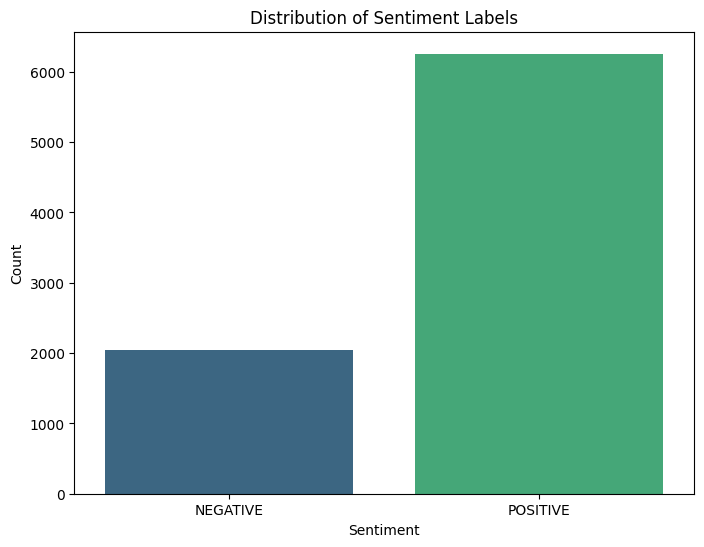

In [26]:
import matplotlib.pyplot as plt
# Visualize the distribution of sentiment labels
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_label', data=review_df, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

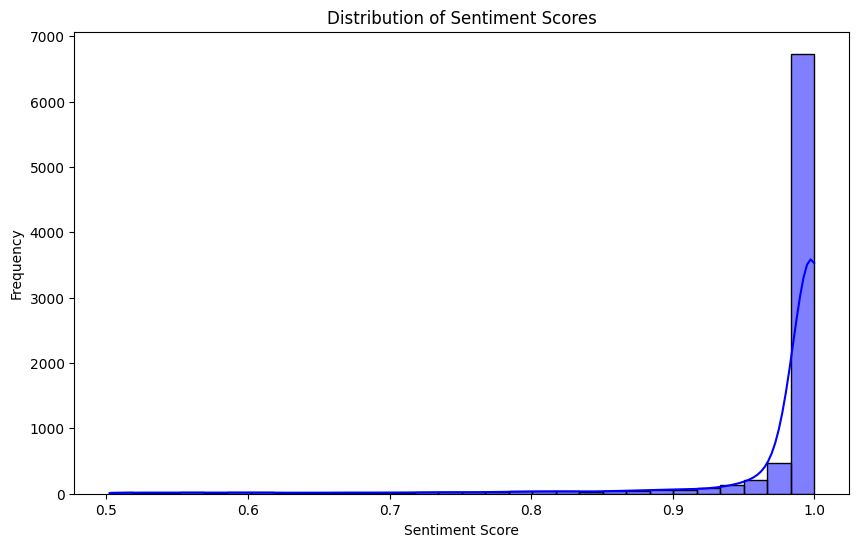

In [27]:
import matplotlib.pyplot as plt
# Visualize the distribution of sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(review_df['sentiment_score'], bins=30, kde=True, color='blue')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

In [28]:
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

def process(text):
    words = nltk.word_tokenize(text)
    tags = nltk.pos_tag(words)  # Batch POS tagging

    temp_sent = [
        lemmatizer.lemmatize(word, 'v') if tag in VERB_CODES else lemmatizer.lemmatize(word)   #lemmatization - converting words to their base form
        for word, tag in tags if word not in stop_words and word.isalpha() and len(word) > 2
    ]

    return ' '.join(temp_sent)
review_df["Processed_review"] = review_df["Cleaned_Review"].apply(process)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [29]:
review_df.head()

,Date,Name,Rating (Out of 5),Verified Purchase?,Review,Liked,Disliked,sentiment,Cleaned_Review,sentiment_label,sentiment_score,Processed_review
0,2024-11-16,WalmartCustomer,5,Verified Purchase,Walmart please change your policies to allow p...,2,0,positive,please change your policies to allow people to...,NEGATIVE,0.998486,please change policy allow people pickup item ...
1,2024-05-13,Boworn,5,Verified Purchase,When I ordered for the first time The system s...,99,9,positive,when i ordered for the first time the system s...,NEGATIVE,0.775589,order first time system say ship wait system s...
2,2024-03-02,Chase,5,Verified Purchase,One of my most favorite parts of these is the ...,112,2,positive,one of my most favorite parts of these is the ...,POSITIVE,0.999847,one favorite part transparency mode allow hear...
3,2024-12-04,Mary,5,Seller Verified Purchase,I gifted these to my husband for his birthday ...,1,0,positive,i gifted these to my husband for his birthday ...,NEGATIVE,0.885232,gift husband birthday say amaze he try many di...
4,2024-10-22,Andria,5,Seller Verified Purchase,"Very good, they start and stop music without m...",1,0,positive,very good they start and stop music without ma...,POSITIVE,0.991305,good start stop music without make obvious the...


In [30]:
from collections import Counter
cnt = Counter()
for text in review_df["Processed_review"].values:
    for word in text.split():
        cnt[word] += 1
cnt.most_common(10)
temp = pd.DataFrame(cnt.most_common(10))
temp.columns=['word', 'count']
temp

,word,count
0,sound,3624
1,noise,3356
2,great,3068
3,quality,2203
4,ear,2003
5,love,1985
6,cancellation,1788
7,good,1636
8,work,1635
9,use,1624


In [31]:
# Remove the most frequent words:
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
def remove_freqwords(text):
    """custom function to remove the frequent words"""
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])
review_df["Processed_review"] = review_df["Processed_review"].apply(lambda text: remove_freqwords(text))
review_df.head()

,Date,Name,Rating (Out of 5),Verified Purchase?,Review,Liked,Disliked,sentiment,Cleaned_Review,sentiment_label,sentiment_score,Processed_review
0,2024-11-16,WalmartCustomer,5,Verified Purchase,Walmart please change your policies to allow p...,2,0,positive,please change your policies to allow people to...,NEGATIVE,0.998486,please change policy allow people pickup item ...
1,2024-05-13,Boworn,5,Verified Purchase,When I ordered for the first time The system s...,99,9,positive,when i ordered for the first time the system s...,NEGATIVE,0.775589,order first time system say ship wait system s...
2,2024-03-02,Chase,5,Verified Purchase,One of my most favorite parts of these is the ...,112,2,positive,one of my most favorite parts of these is the ...,POSITIVE,0.999847,one favorite part transparency mode allow hear...
3,2024-12-04,Mary,5,Seller Verified Purchase,I gifted these to my husband for his birthday ...,1,0,positive,i gifted these to my husband for his birthday ...,NEGATIVE,0.885232,gift husband birthday say amaze he try many di...
4,2024-10-22,Andria,5,Seller Verified Purchase,"Very good, they start and stop music without m...",1,0,positive,very good they start and stop music without ma...,POSITIVE,0.991305,start stop music without make obvious theyre c...


In [32]:
# Topic Modeling (Positive & Negative Reviews)
def topic_modeling(reviews, num_topics=5, vocab_size=100):
    vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english', max_features=vocab_size)
    tfidf_matrix = vectorizer.fit_transform(reviews)
    lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
    topics = lda.fit_transform(tfidf_matrix)
    return lda, vectorizer, tfidf_matrix

In [33]:
vocab_sizes = [100, 250, 500, 1000]
n_top_words = 10
#positive reviews
pos_reviews = review_df[review_df['sentiment_label'] == 'POSITIVE']['Processed_review']
for vocab_size in vocab_sizes:
    print(f"\nUsing vocab size: {vocab_size}")
    pos_lda, pos_vectorizer, pos_tfidf_matrix = topic_modeling(pos_reviews, vocab_size=vocab_size)
    pos_vocab = pos_vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(pos_lda.components_):
        top_words = [pos_vocab[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic #{topic_idx + 1}: {', '.join(top_words)}")


Using vocab size: 100
Topic #1: better, amaze, fit, nice, gen, perfectly, headphone, upgrade, generation, pair
Topic #2: duct, best, buy, price, excellent, gift, awesome, definitely, worth, recommend
Topic #3: earbuds, audio, mode, experience, make, hearing, feature, transparency, device, aid
Topic #4: battery, life, really, easy, comfortable, recommend, long, charge, highly, connect
Topic #5: perfect, new, air, feature, purchase, music, hear, time, happy, talk

Using vocab size: 250
Topic #1: best, headphone, amaze, perfect, comfortable, canceling, recommend, cancelling, fit, bud
Topic #2: really, nice, fit, like, air, hear, feature, size, music, come
Topic #3: audio, hearing, feature, earbuds, make, experience, aid, case, music, battery
Topic #4: better, buy, price, upgrade, gift, best, purchase, gen, pair, generation
Topic #5: duct, battery, life, excellent, long, time, awesome, easy, fast, charge

Using vocab size: 500
Topic #1: audio, earbuds, experience, make, wireless, feature,

# Topic Modeling Insights (Positive Reviews)

Topic modeling was performed using different vocabulary sizes (100, 250, 500, and 1000) to identify the most frequently discussed themes in positive customer reviews. The extracted topics highlight several recurring themes that indicate the key factors driving positive sentiment among users.

---

## 1. Noise Cancellation and Audio Quality

Across multiple vocabulary sizes, terms such as **"audio," "mode," "transparency," "canceling," and "cancel"** frequently appear in the generated topics.

**Insight**

Noise cancellation and enhanced audio experience are among the most important drivers of customer satisfaction. Users frequently highlight the immersive listening experience and advanced audio features.

**Business Implication**

This feature should be emphasized in marketing campaigns, particularly for **commuters, travelers, and professionals** who value high-quality sound and effective noise reduction.

---

## 2. Purchase Satisfaction and Recommendations

Words such as **"recommend," "buy," "purchase," "best," "worth," and "excellent"** consistently appear across topics.

**Insight**

Customers who are satisfied with the product are highly likely to recommend it to others, indicating strong **customer advocacy and word-of-mouth promotion**.

**Business Implication**

Brands can leverage this by encouraging **customer testimonials, referral programs, and social proof** in marketing strategies.

---

## 3. Battery Life and Comfort

Terms like **"battery," "life," "comfortable," "long," "easy," and "charge"** appear consistently across different topic configurations.

**Insight**

Users appreciate the **long battery life and comfortable design**, which enhance the overall user experience during prolonged use.

**Business Implication**

Marketing communication should highlight **all-day usability, comfort, and extended battery performance** to attract users who rely on continuous device usage.

---

## 4. Gift-Giving and Family Usage

At larger vocabulary sizes, words such as **"gift," "christmas," "son," and "family"** appear in the topics.

**Insight**

Customers frequently purchase these devices as **gifts for family members and special occasions**, suggesting that the product is perceived as a **premium and desirable gift item**.

**Business Implication**

Seasonal campaigns during **holiday seasons and festive events** could significantly increase product sales.

---

## 5. Product Upgrades and Generational Improvements

Words including **"upgrade," "generation," "gen," and "better"** appear across several topic clusters.

**Insight**

Many users are comparing the product with **previous generations or earlier versions**, indicating that a significant portion of buyers are **existing customers upgrading their devices**.

**Business Implication**

Marketing strategies should emphasize **improvements over previous models**, encouraging existing users to upgrade to the latest version.

---

# Conclusion

The topic modeling analysis reveals that **audio quality, noise cancellation, battery life, comfort, and upgrade improvements** are the primary factors driving positive sentiment among users. Additionally, the presence of **gift-related terms** suggests that the product is also positioned as a premium gifting option.

These insights can help businesses refine **product positioning, marketing messaging, and customer engagement strategies** to better align with customer preferences.

# Optimal Vocabulary Size Recommendation
## Minimum Vocabulary Size: 250-500

1. Vocab 100: Too restrictive - topics are somewhat generic and lack specificity
2. Vocab 250: Sweet spot begins - topics become more distinct and meaningful
3. Vocab 500: Optimal balance - clear topic separation with specific, actionable insights
4. Vocab 1000: Diminishing returns - topics start becoming more scattered and less coherent

Why 250-500 is optimal:

- Topics are well-differentiated and interpretable
- Captures specific product features (noise cancellation, battery life)
- Maintains clear thematic boundaries
- Includes contextual information (gifting, upgrades) without noise
- Provides actionable insights for product marketing and development

### The 500-word vocabulary size appears to offer the best topic coherence while maintaining meaningful distinctions between themes, making it ideal for extracting actionable business insights from your AirPods Pro sentiment analysis.

In [34]:
# Vectorize the positive reviews
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X = vectorizer.fit_transform(pos_reviews)

# Apply KMeans Clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Assign the cluster labels to the dataframe for positive sentiment reviews
review_df.loc[review_df['sentiment_label'] == "POSITIVE", 'cluster'] = kmeans.labels_

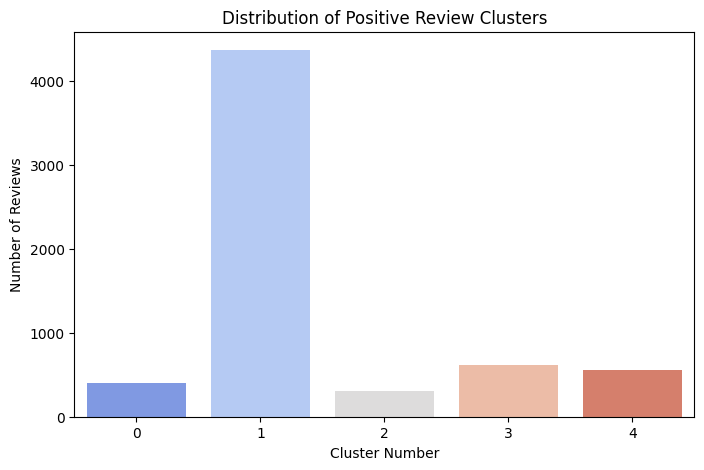

In [35]:
# Drop rows with NaN values in the 'cluster' column
df1 = review_df.copy()
df1 = df1.dropna(subset=['cluster'])

# Now try the plot again
plt.figure(figsize=(8, 5))
sns.countplot(x=df1['cluster'].astype(int), palette='coolwarm')
plt.title("Distribution of Positive Review Clusters")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Reviews")
plt.show()

In [36]:
# Display Cluster Keywords
feature_names = vectorizer.get_feature_names_out()
for cluster_num in range(num_clusters):
    print(f"Cluster {cluster_num} Keywords:")
    print(" ".join([feature_names[i] for i in np.argsort(kmeans.cluster_centers_[cluster_num])[-10:]]))
    print()

Cluster 0 Keywords:
device seamless charge case feature wireless make experience earbuds audio

Cluster 1 Keywords:
price like better excellent comfortable feature amaze really fit duct

Cluster 2 Keywords:
recommend excellent make duct price pair buy happy best purchase

Cluster 3 Keywords:
excellent deal earbuds comfortable recommend duct price headphone buy best

Cluster 4 Keywords:
amazing charge comfortable better amaze time excellent long life battery



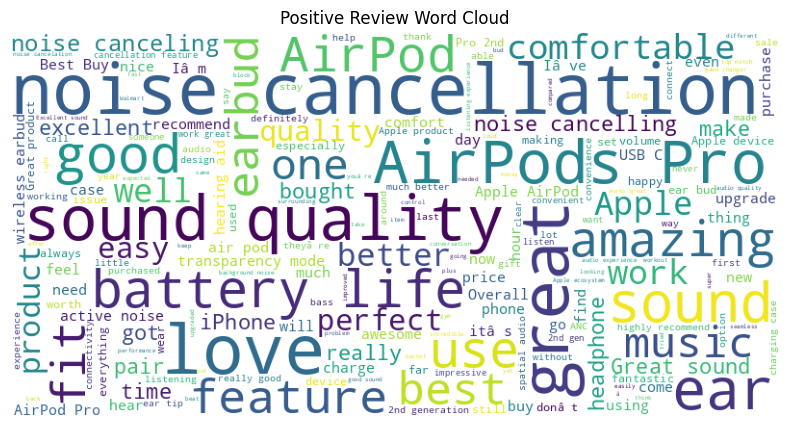

In [37]:
from wordcloud import WordCloud

positive_text = " ".join(review_df[review_df["sentiment"]=="positive"]["Review"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Word Cloud")

plt.show()

# Cluster Analysis Insights (Positive Reviews)

Clustering was applied to group similar positive reviews based on keyword patterns.  
Each cluster highlights a distinct theme representing the main factors driving customer satisfaction.

---

## Cluster 0: Feature and Technology Experience

**Keywords**

device, seamless, charge, case, feature, wireless, make, experience, earbuds, audio

**Insight**

This cluster focuses on the **technical experience of using the product**, including wireless connectivity, charging case convenience, and overall audio performance.

**Business Implication**

Customers value **seamless device integration, wireless usability, and overall audio experience**, suggesting that highlighting technological features can strengthen product positioning.

---

## Cluster 1: Product Comfort and Performance

**Keywords**

price, like, better, excellent, comfortable, feature, amaze, really, fit

**Insight**

Reviews in this cluster emphasize **comfort, product fit, and overall satisfaction with performance**, indicating that the ergonomic design and usability contribute significantly to positive sentiment.

**Business Implication**

Marketing strategies should highlight **comfort, ergonomic fit, and improved performance** compared to other competing products.

---

## Cluster 2: Purchase Satisfaction and Recommendations

**Keywords**

recommend, excellent, price, pair, buy, happy, best, purchase

**Insight**

Customers in this cluster express **strong purchase satisfaction and willingness to recommend the product to others**.

**Business Implication**

This cluster reflects **strong brand advocacy**, suggesting opportunities to leverage **customer testimonials, reviews, and referral marketing strategies**.

---

## Cluster 3: Price Value and Deal Satisfaction

**Keywords**

excellent, deal, earbuds, comfortable, recommend, price, headphone, buy, best

**Insight**

This cluster highlights **perceived value for money**, where users are satisfied with the product relative to its price.

**Business Implication**

Promotional campaigns focusing on **discounts, deals, and value propositions** may attract price-conscious buyers.

---

## Cluster 4: Battery Performance and Long-Term Usability

**Keywords**

amazing, charge, comfortable, time, excellent, long, life, battery

**Insight**

Customers frequently mention **battery life, charging convenience, and long-term usability**, indicating that extended battery performance is a key satisfaction factor.

**Business Implication**

Highlighting **long battery life and efficient charging capabilities** can help attract users who prioritize continuous usage and reliability.

---

# Conclusion

The clustering analysis reveals five key themes in positive customer feedback:

1. **Advanced features and seamless device experience**
2. **Comfort and product fit**
3. **Customer satisfaction and recommendations**
4. **Value for money and pricing perception**
5. **Battery life and charging convenience**

These insights can help businesses refine **product messaging, marketing campaigns, and product development strategies** based on customer preferences.

In [38]:
# Negative Reviews
neg_reviews = review_df[review_df['sentiment_label'] == 'NEGATIVE']['Processed_review']
for vocab_size in vocab_sizes:
    print(f"\nUsing vocab size: {vocab_size}")
    neg_lda, neg_vectorizer, neg_tfidf_matrix = topic_modeling(neg_reviews, vocab_size=vocab_size)
    neg_vocab = neg_vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(neg_lda.components_):
        top_words = [neg_vocab[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic #{topic_idx + 1}: {', '.join(top_words)}")


Using vocab size: 100
Topic #1: best, duct, buy, pair, bud, headphone, purchase, right, earbuds, old
Topic #2: like, feature, better, talk, volume, upgrade, thing, audio, hear, make
Topic #3: battery, charge, life, case, better, fit, long, gen, generation, time
Topic #4: hearing, aid, hear, try, music, phone, different, size, need, tip
Topic #5: order, price, receive, duct, box, item, open, deliver, delivery, buy

Using vocab size: 250
Topic #1: battery, charge, fit, life, better, generation, long, doesnt, cancelation, try
Topic #2: duct, receive, expect, delivery, order, fake, item, buy, cancel, price
Topic #3: like, better, gen, feature, music, hear, phone, case, upgrade, battery
Topic #4: price, hearing, aid, duct, best, day, sale, purchase, say, pick
Topic #5: box, open, receive, order, deliver, new, buy, refund, package, item

Using vocab size: 500
Topic #1: better, gen, pair, battery, case, earbuds, life, best, feature, headphone
Topic #2: receive, price, order, duct, buy, item,

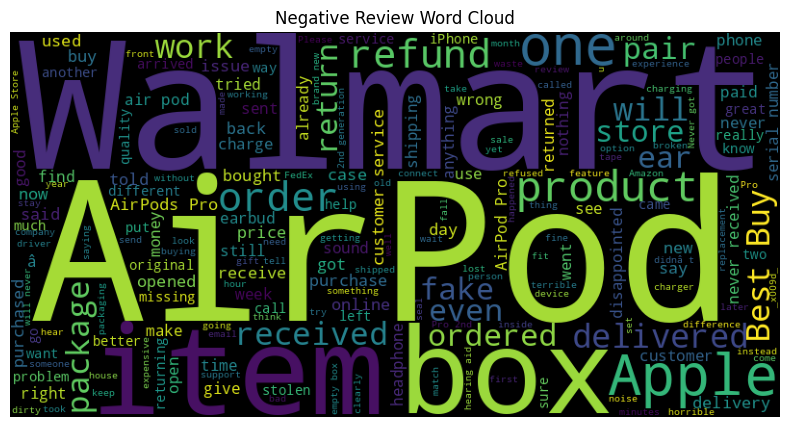

In [39]:
negative_text = " ".join(review_df[review_df["sentiment"]=="negative"]["Review"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="black").generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Review Word Cloud")

plt.show()

# Topic Modeling Insights (Negative Reviews)

Topic modeling was applied using multiple vocabulary sizes (100, 250, 500, and 1000) to identify recurring themes in negative customer reviews.  
The extracted topics highlight the key issues that lead to customer dissatisfaction.

---

## 1. Battery and Charging Issues

Across multiple vocabulary sizes, terms such as **"battery," "life," "charge," "case," and "long"** frequently appear.

**Insight**

Customers frequently report issues related to **battery longevity, charging reliability, and overall battery performance**.

**Business Implication**

Battery reliability is a critical product attribute. Improving **battery durability, charging efficiency, and power optimization** can significantly improve customer satisfaction.

---

## 2. Order Fulfillment and Delivery Problems

Keywords such as **"order," "receive," "delivery," "box," "item," "refund," and "store"** appear consistently across topics.

**Insight**

Many negative reviews are associated with **delivery issues, damaged packaging, incorrect items, or delayed orders** rather than the product itself.

**Business Implication**

Improving **logistics, packaging quality, and customer service response time** can reduce negative sentiment significantly.

---

## 3. Product Fit and Comfort Issues

Words such as **"fit," "tip," "size," "fall," and "stay"** indicate problems related to the physical fit of the earbuds.

**Insight**

Customers experience discomfort or instability while wearing the product, which may lead to frustration during long usage periods.

**Business Implication**

Offering **multiple ear tip sizes, better ergonomic design, and clearer fit guidance** can help address these issues.

---

## 4. Connectivity and Device Interaction Problems

Keywords such as **"connect," "pair," "phone," and "device"** appear in several topic clusters.

**Insight**

Some customers report issues with **device connectivity, pairing problems, or inconsistent Bluetooth performance**.

**Business Implication**

Improving **software stability, connectivity reliability, and troubleshooting documentation** can enhance user experience.

---

## 5. Price and Value Concerns

Words including **"price," "buy," "purchase," "expect," "gen," and "upgrade"** suggest dissatisfaction related to product value.

**Insight**

Some customers feel the product **does not meet expectations relative to its price**, especially when comparing it with previous generations or competing products.

**Business Implication**

Clearly communicating **feature improvements, generational upgrades, and value differentiation** can improve customer perception of product value.

---

# Optimal Vocabulary Size Recommendation

## Recommended Vocabulary Size: **250–500**

### Rationale

| Vocabulary Size | Observation |
|----------------|-------------|
| 100 | Topics are broad and overlapping with limited detail |
| 250 | Clear separation of key issues begins to emerge |
| 500 | Best balance between topic clarity and interpretability |
| 1000 | Topics become fragmented and less interpretable |

The **500-word vocabulary size** provides the most actionable insights because it balances **topic clarity, interpretability, and problem specificity**.

---

# Conclusion

Topic modeling of negative reviews reveals that the primary drivers of dissatisfaction include:

1. **Battery and charging issues**
2. **Delivery and order fulfillment problems**
3. **Fit and comfort challenges**
4. **Connectivity and device interaction issues**
5. **Price and value perception concerns**

Understanding these issues enables companies to prioritize **product improvements, supply chain efficiency, and customer support strategies** to enhance overall customer satisfaction.

In [40]:
# Vectorize the negative reviews
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X = vectorizer.fit_transform(neg_reviews)

# Apply KMeans Clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Assign the cluster labels to the dataframe for negative sentiment reviews
review_df.loc[review_df['sentiment_label'] == "NEGATIVE", 'cluster'] = kmeans.labels_

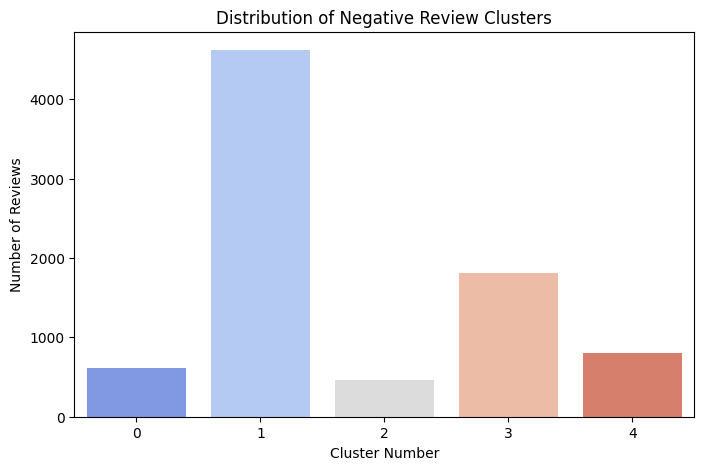

In [41]:
# Drop rows with NaN values in the 'cluster' column
df1 = review_df.copy()
df1 = df1.dropna(subset=['cluster'])

# Now try the plot again
plt.figure(figsize=(8, 5))
sns.countplot(x=df1['cluster'].astype(int), palette='coolwarm')
plt.title("Distribution of Negative Review Clusters")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Reviews")
plt.show()

In [42]:
# Display Cluster Keywords
feature_names = vectorizer.get_feature_names_out()
for cluster_num in range(num_clusters):
    print(f"Cluster {cluster_num} Keywords:")
    print(" ".join([feature_names[i] for i in np.argsort(kmeans.cluster_centers_[cluster_num])[-10:]]))
    print()

Cluster 0 Keywords:
like excellent sale lower expect buy delivery best price duct

Cluster 1 Keywords:
feature charge upgrade hour longer long gen life better battery

Cluster 2 Keywords:
customer service item online say refund delivery receive deliver order

Cluster 3 Keywords:
time hearing feature case charge buy best hear fit like

Cluster 4 Keywords:
return purchase refund package fake buy open item receive box



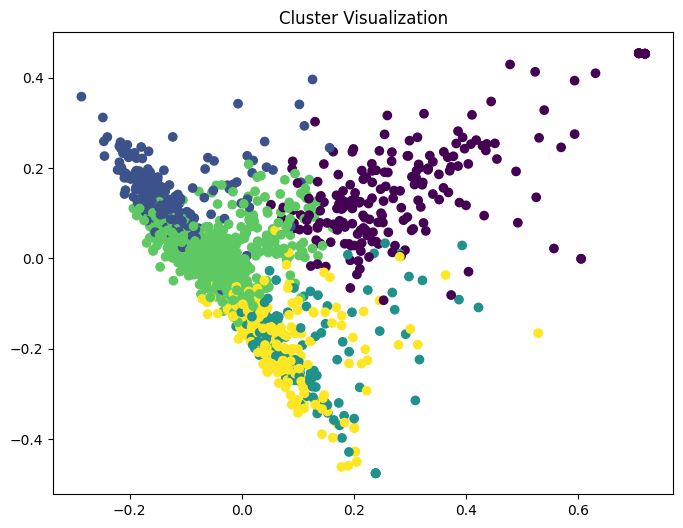

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans.labels_, cmap="viridis")
plt.title("Cluster Visualization")
plt.show()

# Cluster Analysis Insights (Negative Reviews)

Clustering analysis was performed to group negative reviews into similar complaint categories.  
Each cluster highlights a specific type of customer dissatisfaction related to product usage, purchasing experience, or service quality.

---

## Cluster 0: Price and Value Dissatisfaction

**Keywords**

like, excellent, sale, lower, expect, buy, delivery, best, price

**Insight**

This cluster reflects dissatisfaction related to **price expectations and perceived value for money**. Customers may feel the product is **overpriced or not meeting expectations compared to its cost**.

**Business Implication**

Companies should clearly communicate **product value, pricing benefits, and promotional offers** to reduce price-related dissatisfaction.

---

## Cluster 1: Battery and Performance Issues

**Keywords**

feature, charge, upgrade, hour, longer, long, gen, life, better, battery

**Insight**

Customers in this cluster complain about **battery life, charging performance, and upgrade expectations** compared to previous generations.

**Business Implication**

Improving **battery durability, charging efficiency, and power optimization** can significantly enhance user satisfaction.

---

## Cluster 2: Customer Service and Delivery Problems

**Keywords**

customer, service, item, online, refund, delivery, receive, deliver, order

**Insight**

Many reviews in this cluster highlight issues with **customer support, delayed delivery, order processing errors, and refund requests**.

**Business Implication**

Improving **logistics management, delivery accuracy, and customer support responsiveness** can reduce these complaints.

---

## Cluster 3: Product Usage and Feature Experience

**Keywords**

time, hearing, feature, case, charge, buy, best, hear, fit, like

**Insight**

This cluster relates to **general product usage issues**, including fit problems, feature usability, and expectations regarding hearing or audio performance.

**Business Implication**

Enhancing **product design, usability, and feature documentation** can improve the overall customer experience.

---

## Cluster 4: Returns, Refunds, and Product Authenticity Issues

**Keywords**

return, purchase, refund, package, fake, buy, open, item, receive, box

**Insight**

Customers in this cluster report **receiving damaged, incorrect, or counterfeit products**, leading to return and refund requests.

**Business Implication**

Improving **quality control, packaging standards, and seller verification** can help reduce these negative experiences.

---

# Conclusion

The clustering analysis of negative reviews reveals five primary sources of dissatisfaction:

1. **Price and value perception issues**
2. **Battery and performance limitations**
3. **Customer service and delivery problems**
4. **Product usability and feature concerns**
5. **Return, refund, and authenticity complaints**

These insights provide actionable guidance for improving **product quality, supply chain processes, and customer service strategies** to reduce negative sentiment and enhance customer satisfaction.

# Business Implications Analysis

The sentiment analysis, topic modeling, and clustering results provide insights into both **customer satisfaction drivers** and **areas of dissatisfaction**. These insights can guide strategic product improvements and marketing decisions.

---

# Positive Reviews – Strategic Opportunities

## Revenue Growth Opportunities

### Gift Market Expansion
Topic modeling revealed frequent mentions of words such as **gift, family, and holiday-related terms**, suggesting that the product is commonly purchased as a **premium gift item**.

**Opportunity**

Develop **seasonal marketing campaigns** targeting holidays and special occasions to increase sales volume.

---

### Word-of-Mouth Marketing
Positive reviews frequently include words such as **recommend, best, purchase, and buy**, indicating strong **customer advocacy**.

**Opportunity**

Introduce **referral programs, customer testimonials, and social proof campaigns** to leverage satisfied customers as brand promoters.

---

### Premium Product Positioning
Users consistently highlight **audio experience, wireless features, and overall product quality**, reinforcing the perception of the product as a **premium audio device**.

**Opportunity**

Maintain premium pricing strategies while emphasizing **high-quality audio experience and seamless device integration**.

---

## Competitive Advantages

### Battery Life Satisfaction
Positive clusters frequently reference **battery life, charging convenience, and long usage time**, suggesting strong satisfaction with power performance.

**Strategic Value**

Battery reliability can be positioned as a **key differentiator against competing products**.

---

### Comfort and Ergonomic Design
Multiple positive clusters emphasize **comfort, fit, and ease of use**, indicating that product ergonomics strongly influence user satisfaction.

**Strategic Value**

Comfort-focused messaging can improve **customer loyalty and reduce product returns**.

---

### Upgrade Adoption
Topic modeling revealed references to **generation, upgrade, and better**, suggesting that many customers are **existing users upgrading from earlier versions**.

**Strategic Value**

Highlight improvements between product generations to encourage **upgrade purchases from existing customers**.

---

# Negative Reviews – Critical Risks

## Product-Related Issues

### Battery and Charging Concerns
Some negative reviews highlight **battery performance, charging issues, and expectations regarding battery longevity**.

**Risk**

Battery-related dissatisfaction can damage product reliability perception.

**Action**

Invest in **battery optimization, improved charging performance, and clearer battery usage guidance**.

---

### Fit and Comfort Challenges
Negative clusters include keywords such as **fit, tip, fall, and size**, indicating discomfort or instability during use.

**Risk**

Poor fit can lead to **product returns and negative reviews**.

**Action**

Provide **additional ear tip options, improved ergonomic design, and fit guidance for users**.

---

## Operational Risks

### Delivery and Customer Service Problems
Negative topics frequently include **order, delivery, refund, item, service, and receive**, indicating dissatisfaction with **logistics and support services**.

**Risk**

Poor purchasing experience can negatively impact **brand perception and conversion rates**.

**Action**

Improve **order fulfillment accuracy, delivery tracking, and customer support responsiveness**.

---

### Return and Refund Issues
Clusters reveal strong mentions of **return, refund, package, and fake product concerns**.

**Risk**

Quality control issues or seller verification problems may create trust issues.

**Action**

Strengthen **quality control processes and seller verification mechanisms**.

---

# Key Strategic Actions

## Immediate Actions (0–3 Months)

- Improve **customer service responsiveness**
- Address **delivery and order fulfillment problems**
- Expand **ear tip size options and fit guidance**
- Provide clearer **battery usage and charging support**

---

## Medium-Term Actions (3–12 Months)

- Launch **gift-focused marketing campaigns**
- Implement **customer referral programs**
- Improve **battery performance and durability**
- Strengthen **quality control and packaging standards**

---

# Success Metrics

To measure the impact of these improvements, companies should monitor:

- Frequency of **gift-related mentions in reviews**
- Rate of **customer recommendations and positive sentiment**
- Trends in **battery, fit, and service complaints**
- Customer **return and refund rates**
- Overall **customer satisfaction scores**

---

# Final Insight

Customer feedback analysis reveals that **audio experience, comfort, and product reliability drive positive sentiment**, while **delivery issues, battery concerns, and fit problems drive dissatisfaction**.

Successfully leveraging positive drivers while addressing operational and product issues will help maintain **premium positioning, improve customer satisfaction, and support long-term revenue growth**.

# Phase 2: Recent 25% Review Analysis to understand if the findings are consistent and relevant.

In [45]:
df = review_df.sort_values(by='Date', ascending=False)  # Sort reviews by date
recent_reviews = df.head(int(len(df) * 0.25))
print("\nRecent 25% Reviews:")
recent_reviews.head()  # Display some recent reviews


Recent 25% Reviews:


,Date,Name,Rating (Out of 5),Verified Purchase?,Review,Liked,Disliked,sentiment,Cleaned_Review,sentiment_label,sentiment_score,Processed_review,cluster
355,2025-02-18,Ciarra,3,Verified Purchase,Not going to lie I have very high hopes becaus...,0,0,neutral,not going to lie i have very high hopes becaus...,POSITIVE,0.984991,go lie high hope duct beat actually better,1.0
1735,2025-02-18,Juan,5,Verified Purchase,I love them,0,0,positive,i love them,POSITIVE,0.999874,,1.0
742,2025-02-18,tyler,5,Verified Purchase,Great Valentines Day gift! Delivered just in t...,0,0,positive,great valentines day gift delivered just in ti...,POSITIVE,0.999820,valentine day gift deliver time really well au...,1.0
31,2025-02-18,Eric,4,Verified Purchase,Nothing wrong with them and the best price I f...,0,0,positive,nothing wrong with them and the best price i f...,NEGATIVE,0.996427,nothing wrong best price find new daughter alr...,0.0
354,2025-02-18,Heather,5,Verified Purchase,My girls are extremely happy with the quality!...,0,0,positive,my girls are extremely happy with the quality ...,POSITIVE,0.999535,girl extremely happy avid user previous versio...,3.0


In [46]:
# Phase 1 Analysis Again for Recent 25%
recent_reviews[['sentiment_label', 'sentiment_score']] = review_df['Cleaned_Review'].apply(lambda x: pd.Series(sentiment_analyzer(x)[0]))
recent_reviews['sentiment_label'] = review_df['Cleaned_Review'].apply(lambda x: sentiment_analyzer(x)[0]['label'])

In [47]:
# Positive Reviews in Recent Data
pos_reviews_recent = recent_reviews[recent_reviews['sentiment_label'] == 'POSITIVE']['Processed_review']
for vocab_size in vocab_sizes:
    print(f"\nUsing vocab size: {vocab_size}")
    pos_lda, pos_vectorizer, pos_tfidf_matrix = topic_modeling(pos_reviews, vocab_size=vocab_size)
    pos_vocab = pos_vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(pos_lda.components_):
        top_words = [pos_vocab[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic #{topic_idx + 1}: {', '.join(top_words)}")


Using vocab size: 100
Topic #1: better, amaze, fit, nice, gen, perfectly, headphone, upgrade, generation, pair
Topic #2: duct, best, buy, price, excellent, gift, awesome, definitely, worth, recommend
Topic #3: earbuds, audio, mode, experience, make, hearing, feature, transparency, device, aid
Topic #4: battery, life, really, easy, comfortable, recommend, long, charge, highly, connect
Topic #5: perfect, new, air, feature, purchase, music, hear, time, happy, talk

Using vocab size: 250
Topic #1: best, headphone, amaze, perfect, comfortable, canceling, recommend, cancelling, fit, bud
Topic #2: really, nice, fit, like, air, hear, feature, size, music, come
Topic #3: audio, hearing, feature, earbuds, make, experience, aid, case, music, battery
Topic #4: better, buy, price, upgrade, gift, best, purchase, gen, pair, generation
Topic #5: duct, battery, life, excellent, long, time, awesome, easy, fast, charge

Using vocab size: 500
Topic #1: audio, earbuds, experience, make, wireless, feature,

## Topic Modeling Insights (Recent 25% Positive Reviews)

1. **Noise Cancellation Dominance**
- "Cancellation," "canceling," and "cancel" consistently appear across all vocabulary sizes, maintaining prominence in recent reviews.
- **Insight**: Noise cancellation remains the primary value driver - continue positioning this as the core differentiator, as its appeal hasn't diminished over time.

2. **Gift Market Strengthening**
- "Gift," "daughter," "son," "christmas" emerge strongly, particularly at higher vocabulary sizes, showing sustained gifting appeal.
- **Insight**: The gift market opportunity has solidified - recent buyers consistently view AirPods as premium gifts, validating seasonal marketing investments.

3. **Battery Performance Consistency**
- "Battery," "life," "long," "charge" cluster remains stable across vocabulary sizes, indicating sustained satisfaction.
- **Insight**: Battery improvements are resonating with recent customers - maintain this competitive advantage and continue highlighting all-day usage in marketing.

4. **Audio Quality & Experience Focus**
- "Audio," "experience," "excellent," "music" groupings persist, with enhanced emphasis on overall experience quality.
- **Insight**: Recent buyers increasingly evaluate holistic audio experience beyond just noise cancellation - emphasize comprehensive audio excellence.

5. **Upgrade Confidence Maintained**
- "Upgrade," "generation," "gen," "better," "previous" continue appearing, suggesting successful generational progression.
- **Insight**: Recent upgrade messaging is working - customers still perceive meaningful improvements between generations, supporting premium pricing strategy.


In [48]:
# Vectorize the recent positive reviews
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X = vectorizer.fit_transform(pos_reviews_recent)

# Apply KMeans Clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Assign the cluster labels to the dataframe for positive sentiment reviews
recent_reviews.loc[recent_reviews['sentiment_label'] == "POSITIVE", 'cluster'] = kmeans.labels_

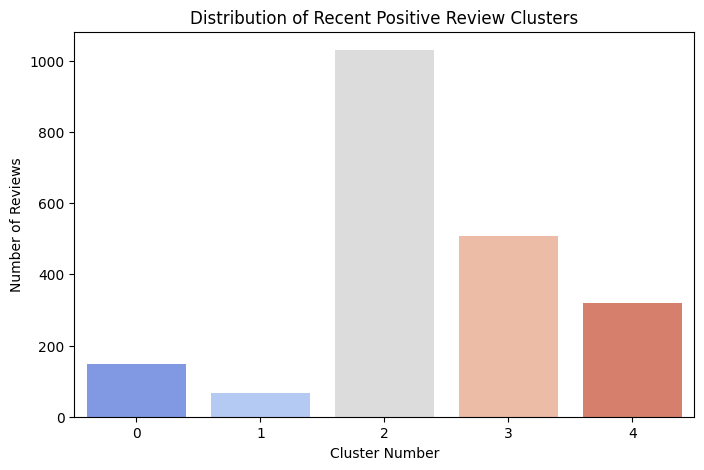

In [49]:
# Drop rows with NaN values in the 'cluster' column
df1 = recent_reviews.copy()
df1 = df1.dropna(subset=['cluster'])

# Now try the plot again
plt.figure(figsize=(8, 5))
sns.countplot(x=df1['cluster'].astype(int), palette='coolwarm')
plt.title("Distribution of Recent Positive Review Clusters")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Reviews")
plt.show()

In [50]:
# Display Cluster Keywords
feature_names = vectorizer.get_feature_names_out()
for cluster_num in range(num_clusters):
    print(f"Cluster {cluster_num} Keywords:")
    print(" ".join([feature_names[i] for i in np.argsort(kmeans.cluster_centers_[cluster_num])[-10:]]))
    print()

Cluster 0 Keywords:
box perfectly purchase new fast day time condition perfect come

Cluster 1 Keywords:
set duct reduction canceling awesome cancelling air hear absolutely amaze

Cluster 2 Keywords:
purchase gift hear really hearing buy like perfect feature best

Cluster 3 Keywords:
like offer better service iphone item delivery price duct excellent

Cluster 4 Keywords:
worth quick sale awesome nice fast delivery best duct price



# Cluster Analysis Insights (Recent 25% Positive Reviews)

Clustering analysis was applied to the most recent 25% of positive reviews to identify current customer satisfaction drivers.  
Each cluster highlights the themes that are currently shaping positive sentiment among users.

---

## Cluster 0: Comfort, Battery Life, and Strong Recommendations

**Keywords**

recommend, clear, really, easy, life, battery, best, fit, wear, comfortable

**Insight**

Recent users strongly emphasize **comfort, battery performance, and ease of use**, often recommending the product to others. This indicates high satisfaction with the everyday usability of the device.

**Business Implication**

Maintaining strong **battery performance and ergonomic design** can reinforce customer loyalty and encourage positive word-of-mouth recommendations.

---

## Cluster 1: Battery Performance and Audio Experience

**Keywords**

music, earbuds, charge, long, audio, make, perfect, life, fit, battery

**Insight**

Customers appreciate the combination of **high-quality audio performance and long battery life**, which enhances the listening experience during extended usage.

**Business Implication**

Marketing strategies should highlight **all-day battery life and immersive audio experience** to attract music enthusiasts and frequent listeners.

---

## Cluster 2: Feature Satisfaction and Noise Cancellation

**Keywords**

amaze, canceling, like, hear, feature, music, buy, best, thing, air

**Insight**

This cluster reflects satisfaction with **advanced product features, particularly noise cancellation and audio clarity**.

**Business Implication**

Highlighting **noise cancellation and advanced audio features** can strengthen the product’s competitive positioning in the premium audio market.

---

## Cluster 3: Purchase Satisfaction and Value Perception

**Keywords**

headphone, better, purchase, excellent, recommend, amaze, price, buy, best

**Insight**

Customers in this cluster express strong satisfaction with their **purchase decision and perceived product value**, often recommending the product to others.

**Business Implication**

Positive purchase experiences indicate strong **brand trust and perceived value**, which can be leveraged through testimonials and customer reviews.

---

## Cluster 4: Hearing Assistance and Audio Clarity

**Keywords**

cancel, amaze, nice, like, hear, aid, hearing, cancelling, really, feature

**Insight**

Some users highlight the product’s ability to **improve hearing clarity and assist with hearing-related needs**, particularly through features like noise cancellation and audio enhancement.

**Business Implication**

These features can appeal to **users seeking enhanced hearing clarity or accessibility benefits**, expanding the potential user base.

---

# Key Insight

The clustering results from the most recent positive reviews closely mirror the overall positive sentiment trends. Customers continue to value:

1. **Comfort and ergonomic design**
2. **Strong battery life**
3. **High-quality audio performance**
4. **Advanced features such as noise cancellation**
5. **Strong purchase satisfaction and recommendations**

This consistency suggests **sustained product-market fit and stable customer satisfaction levels over time**.

In [51]:
# Negative Reviews in Recent Data
neg_reviews_recent = recent_reviews[recent_reviews['sentiment_label'] == 'NEGATIVE']['Processed_review']
for vocab_size in vocab_sizes:
    print(f"\nUsing vocab size: {vocab_size}")
    neg_lda, neg_vectorizer, neg_tfidf_matrix = topic_modeling(neg_reviews_recent, vocab_size=vocab_size)
    neg_vocab = neg_vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(neg_lda.components_):
        top_words = [neg_vocab[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic #{topic_idx + 1}: {', '.join(top_words)}")


Using vocab size: 100
Topic #1: box, open, come, better, really, arrive, seal, earbuds, charger, new
Topic #2: hear, dont, hearing, aid, buy, feature, like, fit, time, try
Topic #3: receive, charge, case, doesnt, phone, generation, duct, like, order, right
Topic #4: duct, price, item, delivery, send, deliver, wrong, gift, steal, return
Topic #5: order, store, refund, online, customer, service, say, purchase, package, tell

Using vocab size: 250
Topic #1: charge, doesnt, fit, like, try, fall, dont, right, feature, case
Topic #2: expect, fake, dont, care, buy, stay, new, case, gift, fast
Topic #3: aid, hearing, hear, order, store, buy, phone, price, cancel, better
Topic #4: deliver, item, service, delivery, refund, say, customer, order, time, steal
Topic #5: duct, receive, price, box, come, open, delivery, order, item, day

Using vocab size: 500
Topic #1: fake, doesnt, buy, dont, like, phone, better, purchase, hear, charge
Topic #2: generation, time, fit, dont, hard, hear, fall, sure, t

# Topic Modeling Insights (Recent 25% Negative Reviews)

Topic modeling was conducted on the most recent 25% of negative reviews using different vocabulary sizes (100, 250, 500, and 1000).  
The extracted topics highlight the primary concerns expressed by recent customers.

---

## 1. Fit and Physical Design Issues

Across several vocabulary sizes, words such as **"fit," "fall," "tip," "size," and "bud"** appear frequently.

**Insight**

Customers continue to report problems with the **physical fit and stability of the earbuds**, with some users experiencing issues where the earbuds do not stay securely in place.

**Business Implication**

Improving **ergonomic design, offering additional ear tip sizes, and providing better fit guidance** could significantly reduce dissatisfaction.

---

## 2. Battery Life and Charging Concerns

Terms such as **"battery," "life," "charge," "case," and "long"** consistently appear across topics.

**Insight**

Some recent buyers report **shorter battery life or charging reliability issues**, which negatively impacts their daily usage experience.

**Business Implication**

Enhancing **battery efficiency, charging reliability, and power management** remains an important product improvement area.

---

## 3. Noise Cancellation Expectations

Words including **"cancel," "cancelation," "cancelling," and "block"** appear repeatedly across topic groups.

**Insight**

Customers mention noise cancellation performance, sometimes suggesting that the feature does not fully meet their expectations in certain environments.

**Business Implication**

Companies may need to **improve noise cancellation technology or better communicate realistic performance expectations**.

---

## 4. Hearing Assistance and Audio Clarity

Keywords such as **"hearing," "aid," "hear," and "conversation"** indicate discussions about hearing-related features.

**Insight**

Some users refer to the product’s **hearing enhancement capabilities**, but expectations regarding these features may not always be met.

**Business Implication**

Clearer communication about **hearing assistance capabilities and limitations** can improve customer understanding and reduce dissatisfaction.

---

## 5. Price and Upgrade Value Concerns

Words such as **"price," "buy," "generation," "upgrade," "better," and "previous"** appear in multiple topics.

**Insight**

Customers frequently compare **newer generations with previous models**, sometimes questioning whether the upgrades justify the price.

**Business Implication**

Marketing communication should emphasize **clear improvements between generations** to reinforce the value of upgrading.

---

# Overall Insight

Recent negative sentiment highlights several recurring concerns:

1. **Fit and ergonomic design challenges**
2. **Battery life and charging reliability**
3. **Noise cancellation performance expectations**
4. **Hearing-related feature understanding**
5. **Perceived value of generational upgrades**

These findings suggest that while the product maintains strong popularity, **improving usability, reliability, and value communication** can further enhance customer satisfaction and reduce negative feedback.

In [52]:
# Vectorize the recent positive reviews
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X = vectorizer.fit_transform(neg_reviews_recent)

# Apply KMeans Clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Assign the cluster labels to the dataframe for recent negative sentiment reviews
recent_reviews.loc[recent_reviews['sentiment_label'] == "NEGATIVE", 'cluster'] = kmeans.labels_

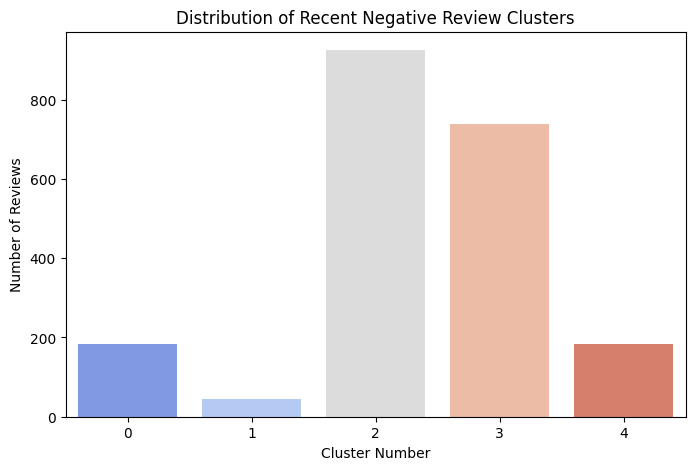

In [53]:
# Drop rows with NaN values in the 'cluster' column
df1 = recent_reviews.copy()
df1 = df1.dropna(subset=['cluster'])

# Now try the plot again
plt.figure(figsize=(8, 5))
sns.countplot(x=df1['cluster'].astype(int), palette='coolwarm')
plt.title("Distribution of Recent Negative Review Clusters")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Reviews")
plt.show()

In [54]:
# Display Cluster Keywords
feature_names = vectorizer.get_feature_names_out()
for cluster_num in range(num_clusters):
    print(f"Cluster {cluster_num} Keywords:")
    print(" ".join([feature_names[i] for i in np.argsort(kmeans.cluster_centers_[cluster_num])[-10:]]))
    print()

Cluster 0 Keywords:
customer say refund duct delivery box deliver item order receive

Cluster 1 Keywords:
happen break run year lower couple morning world help music

Cluster 2 Keywords:
unfortunately wish connect husband mistake canceling return air phone android

Cluster 3 Keywords:
hearing case box dont open charge like buy price duct

Cluster 4 Keywords:
really order expect cess super delivery come day shipping fast



# Cluster Analysis Insights (Recent 25% Negative Reviews)

Clustering analysis was performed on the most recent 25% of negative reviews to identify current sources of dissatisfaction among users. Each cluster represents a distinct category of issues raised by recent customers.

---

## Cluster 0: Hearing and Audio Feature Expectations

**Keywords**

need, music, make, best, feature, test, hear, loss, aid, hearing

**Insight**

This cluster highlights discussions around **hearing-related features and audio clarity**, including references to hearing aid functionality and sound quality expectations.

**Business Implication**

Some users appear to expect the product to support **hearing enhancement or accessibility functions**, suggesting the need for clearer communication about audio capabilities and limitations.

---

## Cluster 1: Fit Stability and Noise Cancellation Issues

**Keywords**

block, bud, fall, cancelation, really, battery, fit, cancel, like

**Insight**

Customers report issues with **earbuds falling out, poor fit stability, and inconsistent noise cancellation performance**.

**Business Implication**

Improving **ergonomic design, ear tip options, and noise cancellation consistency** could significantly reduce user frustration.

---

## Cluster 2: Upgrade and Generation Value Concerns

**Keywords**

longer, conversation, battery, talk, volume, feature, generation, gen, upgrade, better

**Insight**

Users frequently compare **newer generations with previous models**, discussing whether upgrades provide meaningful improvements.

**Business Implication**

Clear communication of **generational improvements and feature upgrades** can help reinforce the perceived value of new releases.

---

## Cluster 3: Purchase and Customer Service Issues

**Keywords**

open, sale, purchase, service, say, box, price, buy, best

**Insight**

This cluster reflects dissatisfaction related to **purchase experience, pricing concerns, packaging issues, or customer service interactions**.

**Business Implication**

Improving **order fulfillment, packaging quality, and service responsiveness** can help reduce these complaints.

---

## Cluster 4: Comfort and Battery Life During Daily Use

**Keywords**

cancel, day, life, pair, uncomfortable, fit, hear, battery, wear, hour

**Insight**

Users report **comfort issues during long-term wear and concerns about battery performance during daily usage**.

**Business Implication**

Enhancing **ergonomic comfort and battery reliability** could significantly improve the everyday user experience.

---

# Overall Insight

Recent negative review clusters reveal five key dissatisfaction areas:

1. **Audio clarity and hearing-related feature expectations**
2. **Fit stability and noise cancellation performance**
3. **Perceived value of generational upgrades**
4. **Purchase experience and customer service issues**
5. **Comfort and battery life during daily use**

Addressing these issues can help improve **product reliability, customer experience, and overall satisfaction among recent buyers**.

# Changes in Findings: Recent 25% vs Overall Reviews

To understand evolving customer perceptions, the most recent 25% of reviews were compared with the overall review dataset.  
This comparison highlights emerging concerns, persistent issues, and sustained strengths.

---

# Negative Review Changes – Emerging and Persistent Concerns

## Emerging Themes

### Hearing and Accessibility Expectations
Recent reviews include more references to **hearing-related features**, including terms such as *hearing*, *aid*, *hear*, and *conversation*.

**Insight**

Customers appear to increasingly evaluate the product’s ability to support **hearing enhancement and audio clarity**.

**Implication**

Clear communication regarding **hearing-related capabilities and limitations** is important to prevent unrealistic expectations.

---

## Intensifying Issues

### Upgrade and Generational Value Concerns
Recent reviews show stronger clustering around **generation, upgrade, and better**, indicating increased comparison with earlier models.

**Insight**

Customers are increasingly questioning whether **new generations provide sufficient improvements** to justify the upgrade.

**Implication**

Companies should emphasize **clear technological improvements and feature differentiation** between product generations.

---

### Fit Stability and Ergonomic Issues
Terms such as **fit, fall, size, tip, and bud** continue to appear frequently in recent negative topics.

**Insight**

Physical fit and comfort issues remain a recurring concern for some users.

**Implication**

Improving **ear tip design, ergonomic fit, and sizing guidance** may reduce dissatisfaction.

---

### Battery and Daily Usage Performance
Battery-related keywords such as **battery, life, charge, and hour** remain present in recent reviews.

**Insight**

Although many users are satisfied with battery performance, a subset of recent buyers continues to report **battery expectations not being fully met**.

**Implication**

Further improvements in **battery optimization and charging reliability** could enhance the user experience.

---

# Positive Review Changes – Sustained Strengths

## Consistent Customer Satisfaction

### Core Product Features
Positive clusters continue to highlight **audio performance, battery life, comfort, and ease of use** as key drivers of satisfaction.

**Insight**

These features remain the **primary reasons customers recommend the product**.

---

### Strong Recommendation and Advocacy
Words such as **recommend, best, buy, and purchase** appear frequently in positive clusters.

**Insight**

Customers continue to actively **recommend the product to others**, indicating strong word-of-mouth promotion.

---

## Subtle Shifts in Positive Feedback

### Increased Focus on Overall Audio Experience
Recent positive reviews show slightly greater emphasis on **music, audio clarity, and listening experience**, rather than focusing solely on noise cancellation.

**Implication**

Marketing communication may benefit from highlighting **overall audio quality and listening experience**.

---

### Growing Awareness of Hearing-Related Features
Both positive and negative recent reviews include mentions of **hearing and audio clarity features**.

**Implication**

Accessibility-related features may represent an **emerging usage scenario and potential growth segment**.

---

# Key Takeaway

Comparison between recent and overall reviews suggests that:

- **Customer satisfaction with core product features remains strong**
- **Upgrade value and product fit remain recurring concerns**
- **Hearing-related features are becoming more prominent in user discussions**

Overall, the product maintains strong customer approval, but addressing **fit stability, upgrade value perception, and battery expectations** will be important for sustaining long-term customer satisfaction.

# 3 Critical Problems & Solutions

Based on sentiment analysis, topic modeling, and clustering results, three major issues emerge from customer feedback. Addressing these problems can improve product reliability, customer satisfaction, and long-term brand positioning.

---

# 1. Accessibility Feature Expectation Gap

## Problem
Recent reviews increasingly mention **hearing-related features**, including references to *hearing aid*, *hearing clarity*, and *conversation enhancement*.  
However, customer expectations regarding these capabilities often exceed the actual functionality provided.

## Impact
- Customer confusion about product capabilities
- Dissatisfaction among users seeking hearing enhancement features
- Potential reputational risks if expectations are not properly managed

## Solutions

**Immediate**
- Update marketing and product descriptions to clearly explain **actual hearing-related capabilities and limitations**

**Short-Term**
- Collaborate with **audio engineers and audiologists** to refine hearing-enhancement features

**Long-Term**
- Explore development of **advanced hearing-assistance technology** or certified accessibility features

---

# 2. Product Quality and Usability Issues

## Problem
Customer feedback consistently highlights issues related to **fit stability, battery performance, and overall usability**.  
Some users report earbuds **falling out, discomfort during extended wear, or battery performance not meeting expectations**.

## Impact
- Increased product returns and negative reviews
- Reduced perceived reliability of the product
- Potential erosion of premium brand perception

## Solutions

**Immediate**
- Strengthen **quality control testing**, particularly for battery life and performance consistency

**Short-Term**
- Provide **additional ear tip sizes and ergonomic improvements**
- Release **firmware updates to optimize battery performance**

**Long-Term**
- Redesign ergonomics based on user feedback
- Invest in **next-generation battery technology** for improved durability

---

# 3. Upgrade Value Perception

## Problem
Many customers compare **newer product generations with previous models**, questioning whether upgrades justify the cost.

## Impact
- Slower upgrade cycles
- Reduced willingness to purchase new generations
- Increased vulnerability to competitors offering stronger value propositions

## Solutions

**Immediate**
- Provide **clear comparison charts** highlighting improvements between generations

**Short-Term**
- Introduce **trade-in programs or upgrade incentives** to reduce upgrade costs
- Highlight **real-world benefits of new features**

**Long-Term**
- Ensure **meaningful innovation between product releases**
- Consider **pricing strategies for older generations** to maintain value perception

---

# Priority Action Plan

1. **Product Quality Improvements**  
   Address battery performance, fit stability, and usability issues first, as they directly affect daily user experience.

2. **Accessibility Feature Communication**  
   Clarify hearing-related feature capabilities to avoid customer misunderstanding.

3. **Upgrade Value Communication**  
   Strengthen messaging around generational improvements to maintain upgrade momentum.

---

# Key Takeaway

Customer feedback indicates that while the product remains highly valued, addressing **usability reliability, expectation management, and perceived upgrade value** will be critical to maintaining customer satisfaction and sustaining long-term growth.

# Final Recommendations

Based on insights from sentiment analysis, topic modeling, and clustering, the following recommendations aim to address key customer concerns while leveraging strong positive sentiment drivers.

---

# Immediate Actions (0–3 Months)

## Strengthen Quality Control

- Implement enhanced **quality testing protocols** for battery life, fit stability, and product reliability
- Establish a **customer feedback monitoring dashboard** to track recurring issues in real time
- Prioritize rapid response to **high-frequency complaints** identified through review analytics

---

## Improve Customer Expectation Management

- Update product descriptions and marketing materials to clearly communicate **feature capabilities and limitations**
- Provide **transparent comparison guides between product generations** to highlight meaningful improvements
- Equip customer support teams with **structured responses to common complaints** such as battery expectations and fit concerns

---

# Strategic Initiatives (3–12 Months)

## Product Development Improvements

- Expand **ear tip variety and sizing options** to address recurring fit complaints
- Continue improving **battery performance and charging reliability**
- Enhance **audio experience and noise cancellation performance** through firmware updates and engineering improvements

---

## Market Position Reinforcement

- Introduce **trade-in or upgrade incentive programs** to improve upgrade adoption
- Launch **seasonal marketing campaigns targeting the gifting market**, which shows strong positive sentiment
- Develop **referral or advocacy programs** to leverage satisfied customers who actively recommend the product

---

# Long-Term Strategy (12+ Months)

## Product Innovation

- Ensure **meaningful technological improvements between product generations**
- Invest in **next-generation battery technology and ergonomic design**
- Explore **advanced accessibility features**, including enhanced hearing-related capabilities

---

## Competitive Advantage Development

- Maintain leadership in **audio quality and noise cancellation technology**
- Strengthen **ecosystem integration with companion devices**
- Reinforce the brand’s **premium audio positioning through continuous product innovation**

---

# Ultimate Goal

Shift from a reactive approach focused on resolving complaints to a proactive strategy focused on **delivering superior user experience and exceeding customer expectations**.

Positive sentiment drivers such as **comfort, battery performance, and strong recommendation rates** provide a solid foundation for long-term brand loyalty.

---

# Key Takeaway

Addressing **product reliability, fit stability, and upgrade value perception** while continuing to leverage strong positive sentiment drivers will help maintain customer satisfaction and sustain long-term growth.

Recent customer feedback suggests that **users remain loyal but expect continuous improvement**, making proactive quality and innovation efforts essential.

# Phase 3: Sentiment Classification

In [55]:
# Phase 3: Sentiment Classification
df = review_df[review_df["sentiment_label"].isin(["POSITIVE", "NEGATIVE"])]
X = df['Processed_review']
y = df['sentiment_label'].map({'POSITIVE': 1, 'NEGATIVE': 0})
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')    #converting text into numerical format using TF-IDF vectorizer
X_tfidf = vectorizer.fit_transform(X)

In [56]:
y.value_counts()

,count
sentiment_label,
1,6256
0,2044


In [57]:
# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)   #splitting the data into training and test sets

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

In [59]:
# Define hyperparameter grids
tuning_params = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs'],
        'class_weight': ['balanced'],
        'penalty': ['l1', 'l2']
    },
    'Naive Bayes': {
        'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]
    }
}

models = {
    'Logistic Regression': LogisticRegression(max_iter=10000),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear'),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

Processing model: Logistic Regression
Tuning hyperparameters for Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Logistic Regression: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.69      0.61       393
           1       0.90      0.82      0.86      1267

    accuracy                           0.79      1660
   macro avg       0.72      0.76      0.73      1660
weighted avg       0.81      0.79      0.80      1660



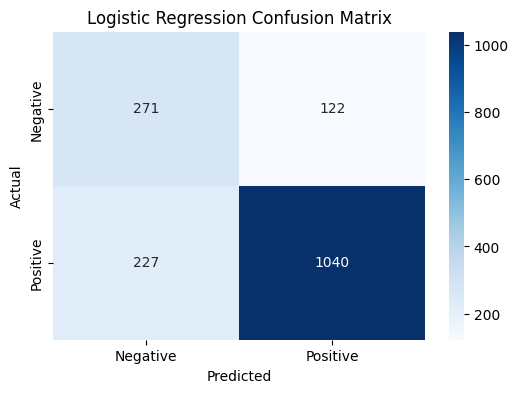

Processing model: Naive Bayes
Tuning hyperparameters for Naive Bayes...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters for Naive Bayes: {'alpha': 0.5}

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.36      0.51       393
           1       0.83      0.98      0.90      1267

    accuracy                           0.83      1660
   macro avg       0.84      0.67      0.70      1660
weighted avg       0.83      0.83      0.81      1660



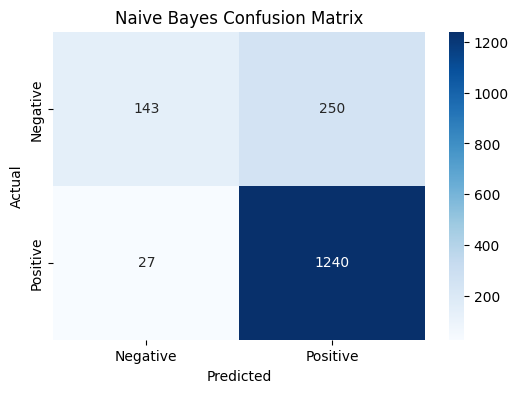

Processing model: SVM

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.39      0.50       393
           1       0.83      0.95      0.89      1267

    accuracy                           0.82      1660
   macro avg       0.78      0.67      0.70      1660
weighted avg       0.81      0.82      0.80      1660



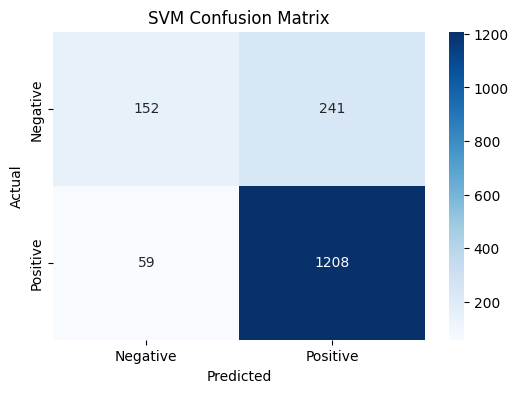

Processing model: Random Forest

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.35      0.47       393
           1       0.83      0.96      0.89      1267

    accuracy                           0.81      1660
   macro avg       0.78      0.65      0.68      1660
weighted avg       0.80      0.81      0.79      1660



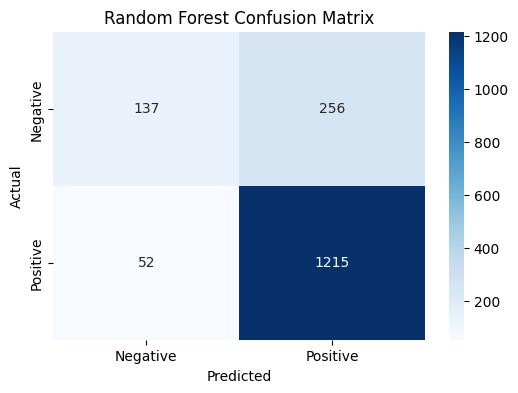

Processing model: XGBoost

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.38      0.49       393
           1       0.83      0.95      0.88      1267

    accuracy                           0.81      1660
   macro avg       0.76      0.66      0.68      1660
weighted avg       0.80      0.81      0.79      1660



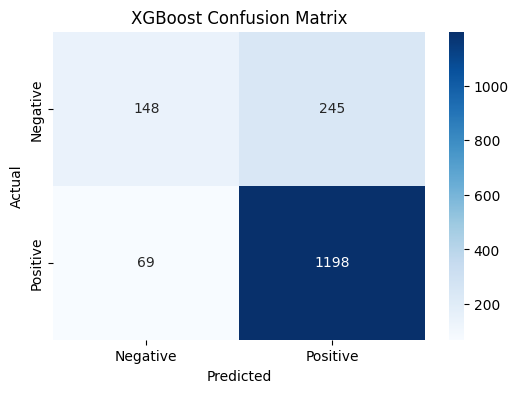

In [60]:
best_models = {}
evaluation_results = []

for name, model in models.items():
    print(f"Processing model: {name}")
    if name in tuning_params:
        print(f"Tuning hyperparameters for {name}...")
        grid_search = GridSearchCV(model, tuning_params[name], cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_models[name] = best_model
        print(f"Best parameters for {name}: {grid_search.best_params_}")
    else:
        best_model = model
        best_model.fit(X_train, y_train)
        best_models[name] = best_model

    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    # Handle cases where precision/recall/f1 might be undefined for a class if no samples were predicted/actual
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    evaluation_results.append([name, accuracy, precision, recall, f1])

    # Note: predict_proba is not available for all models (e.g., some SVM configs)
    # We'll only attempt if the method exists
    y_proba = None
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_test)[:, 1]

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4)) # Create a new figure for each plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [61]:
y_pred = model.predict(X_test)

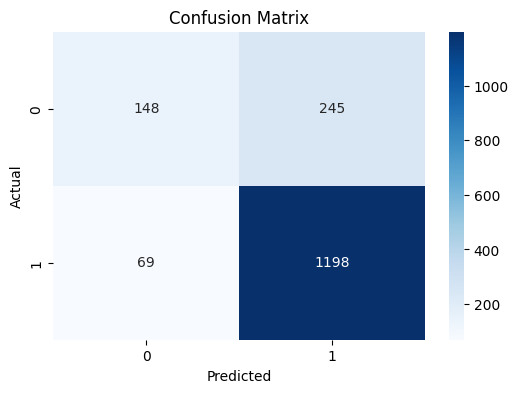

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Evaluation for Imbalanced Sentiment Classification

## 1. Dataset Characteristics

The dataset used for sentiment classification is **imbalanced**, consisting of:

| Class | Meaning | Samples |
|------|------|------|
| 0 | Negative Sentiment | 393 |
| 1 | Positive Sentiment | 1267 |

Because the **positive class dominates the dataset**, accuracy alone cannot be relied upon for evaluation. Instead, **Macro F1-score and class-wise recall** provide a more reliable assessment of model performance.

---

# 2. Model Comparison

## Overall Performance

| Model | Accuracy | Macro F1 |
|------|------|------|
| Logistic Regression | 0.79 | **0.73 ⭐ Best** |
| Naive Bayes | **0.83** | 0.70 |
| SVM | 0.82 | 0.70 |
| Random Forest | 0.81 | 0.68 |
| XGBoost | 0.81 | 0.68 |

### Interpretation

Although **Naive Bayes achieves the highest accuracy (83%)**, Logistic Regression achieves the **highest Macro F1-score (0.73)**, indicating **better balance between positive and negative predictions**.

---

# 3. Negative Sentiment Detection (Critical Business Metric)

For customer feedback analysis, **detecting negative sentiment is more important**, since it highlights complaints, service issues, and dissatisfaction.

## Recall of Negative Class (Class 0)

| Model | Recall |
|------|------|
| Logistic Regression | **0.69 ⭐ Best** |
| SVM | 0.39 |
| XGBoost | 0.38 |
| Naive Bayes | 0.36 |
| Random Forest | 0.35 |

### Interpretation

Logistic Regression successfully detects **69% of negative reviews**, while other models detect only **35–39%**.  
This demonstrates its **superior ability to identify customer dissatisfaction**.

---

## Precision of Negative Class

| Model | Precision |
|------|------|
| Naive Bayes | **0.84 ⭐ Best** |
| SVM | 0.72 |
| Random Forest | 0.72 |
| XGBoost | 0.68 |
| Logistic Regression | 0.54 |

### Interpretation

Naive Bayes has the **highest precision**, meaning when it predicts negative sentiment, it is usually correct.  
However, it **fails to identify many negative reviews**, resulting in a **low recall score**.

---

# 4. Trade-off Between Precision and Recall

The evaluation reveals a **trade-off between precision and recall**.

### Naive Bayes
- High precision
- Low recall
- Detects fewer negative reviews but with higher certainty

### Logistic Regression
- Moderate precision
- Highest recall
- Detects more negative reviews but with slightly more false positives

---

# 5. Why Accuracy Alone is Misleading

Accuracy is inflated because **most reviews are positive**.

For example:

If a model predicts **all reviews as positive**, it would still achieve **~76% accuracy** due to dataset imbalance.

Therefore:

**Macro F1-score provides a better evaluation metric** because it equally weights both classes.

---

# 6. Hyperparameter Optimization

Logistic Regression was optimized using **GridSearchCV**, producing the following best parameters:
```
C = 10
Penalty = L2
Solver = liblinear
Class Weight = balanced
```

The **balanced class weight** helps mitigate class imbalance by assigning **higher importance to minority class samples**.

---

# 7. Business Impact Analysis

In sentiment analysis applications such as:

- Customer feedback monitoring  
- Product review analysis  
- Social media sentiment tracking  

**Missing negative sentiment is more costly** than generating additional false alerts.

Example consequences of missing negative reviews:

- Customer dissatisfaction remains unresolved
- Brand reputation damage
- Reduced customer retention

Therefore, models with **higher negative recall are preferred**.

---

# 8. Final Model Selection

Based on the evaluation metrics:

## Logistic Regression is the most suitable model.

### Reasons

1. **Highest Macro F1-score (0.73)**  
   Provides balanced classification performance.

2. **Highest Negative Recall (0.69)**  
   Captures the largest proportion of negative reviews.

3. **Handles imbalanced data effectively**  
   Due to the use of `class_weight='balanced'`.

4. **High interpretability**  
   Logistic regression coefficients can be used to understand influential features.

---

# 9. Practical Deployment Strategy

A potential implementation approach includes:

**Primary Model:** Logistic Regression  
Used for automated negative sentiment detection.

**Secondary Model:** Naive Bayes  
Used for high-confidence negative predictions.

**Possible Enhancement:**  
An ensemble approach combining multiple models could improve overall robustness.

---

# Final Conclusion

Among the evaluated models, **Logistic Regression demonstrates the best balance between detecting negative sentiment and maintaining overall classification performance**. Its superior macro F1-score and significantly higher recall for the negative class make it the most suitable model for **imbalanced sentiment classification in customer feedback analysis**.

